<a href="https://colab.research.google.com/github/episode16/Py/blob/master/test/test_okkam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Тестовое задание в Okkam

## Основная задача: построить регрессионную модель предсказания зависимой величины с помощью предоставленных факторов. Подзадачи:

In [343]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [344]:
!gdown 1-Y7YeW8JD49843va8WjxdLQwfEGQQ6uHPJ9WA-UtWhI


Downloading...
From (original): https://drive.google.com/uc?id=1-Y7YeW8JD49843va8WjxdLQwfEGQQ6uHPJ9WA-UtWhI
From (redirected): https://docs.google.com/spreadsheets/d/1-Y7YeW8JD49843va8WjxdLQwfEGQQ6uHPJ9WA-UtWhI/export?format=xlsx
To: /content/data_for_test.xlsx
33.6kB [00:00, 69.9MB/s]


### a) провести разведочный анализ данных (описательные статистики, распределения, сводные таблицы, графики), среди графиков желателен график динамики целевой величины с отметками периодов рекламной активности; содержательно описать результаты анализа;

In [345]:
df = pd.read_excel('./data_for_test.xlsx', 'Raw data', index_col=None)
df.to_csv('data_for_test.csv', encoding='utf-8')

description_data = pd.read_excel('./data_for_test.xlsx', 'Data description', index_col=None)
description_data.to_csv('data_for_test.csv', encoding='utf-8')
description_data

,Наименование фактора,Описание фактора (единицы измерения)
0,Date,Дата (дни с 1 января 2013 года по 1 февраля 20...
1,Y,Целевой показатель - суммарное количество теле...
2,TV,Показатель медиа активности на национальном те...
3,OOH,OTS по наружной рекламе - оценка числа контакт...
4,Seasonal_Sales,Нормированная в шкалу от 0 (минимум) до 1 (мак...
5,usd_rate,Курс доллара по Yahoo Finance (рублей за 1 дол...


In [346]:
print(df.info())

print(f"\nfirst 3 lines in df:\n{df.head(3)}")

print(f"\nNaNs in table:\n{df.isna().sum()}\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 762 entries, 0 to 761
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            762 non-null    datetime64[ns]
 1   Y               759 non-null    float64       
 2   TV              762 non-null    int64         
 3   OOH             762 non-null    float64       
 4   Seasonal_Sales  762 non-null    float64       
 5   Usd_rate        762 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 35.8 KB
None

first 3 lines in df:
        Date     Y  TV  OOH  Seasonal_Sales   Usd_rate
0 2013-01-01   NaN   0  0.0        0.060802  30.502001
1 2013-01-02   0.0   0  0.0        0.060802  30.337200
2 2013-01-03  17.0   0  0.0        0.060802  30.156500

NaNs in table:
Date              0
Y                 3
TV                0
OOH               0
Seasonal_Sales    0
Usd_rate          0
dtype: int64



Видим, что 3 значения Y пропущено. Глядя на сам датасет, отсутсвуют 3 дня из 2 лет, или 0.4% данных со всего датасета.

In [347]:
df = df.dropna(subset=['Y'])

### Разведочный анализ

Основные метрики каждого признака

In [348]:
df.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
Date,759,2014-01-16 13:28:13.280632320,2013-01-02 00:00:00,2013-07-10 12:00:00,2014-01-17 00:00:00,2014-07-25 12:00:00,2015-02-01 00:00:00,NaN
Y,759.0,23.627141,0.0,16.0,21.0,27.0,176.0,15.08155
TV,759.0,1044.12253,0.0,0.0,0.0,0.0,26310.0,3652.305315
OOH,759.0,470.498024,0.0,0.0,0.0,0.0,145137.0,6220.595044
Seasonal_Sales,759.0,0.461595,0.0,0.062488,0.360924,0.7597,1.0,0.352874
Usd_rate,759.0,36.311265,29.883301,32.113201,33.4133,36.031149,68.735001,7.98544


Описательная статистика:
- Целевая переменная Y (звонки) имеет среднее значение ~23.6 и широкий разброс (от 0 до 176) и стандартное отклонение 15
- Медиаактивность (TV) в среднем ~1040 контакта (тыс.), но с большими колебаниями (до 26310).
- Наружная реклама (OOH) в среднем ~467 контактов (тыс.), но часто равна 0 (медиана 0).
- Сезонность продаж колеблется от 0.06 до 0.94 (нормировано).
- Курс доллара варьируется от 29.88 до 68.73 руб.

### Анализ целевой переменной Y

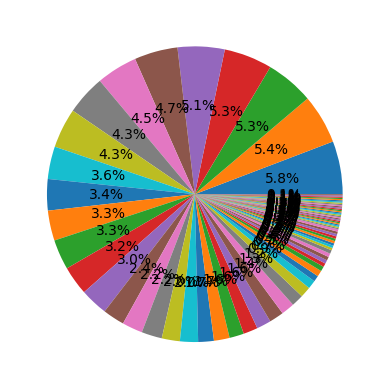

In [349]:
data_y = df['Y'].value_counts()
plt.pie(data_y, autopct='%1.1f%%')

plt.show()

value counts:
Y
18.0     44
20.0     41
15.0     40
23.0     40
21.0     39
         ..
105.0     1
133.0     1
90.0      1
83.0      1
51.0      1
Name: count, Length: 76, dtype: int64

Mean rate: 23.627140974967062

Median rate: 21.0


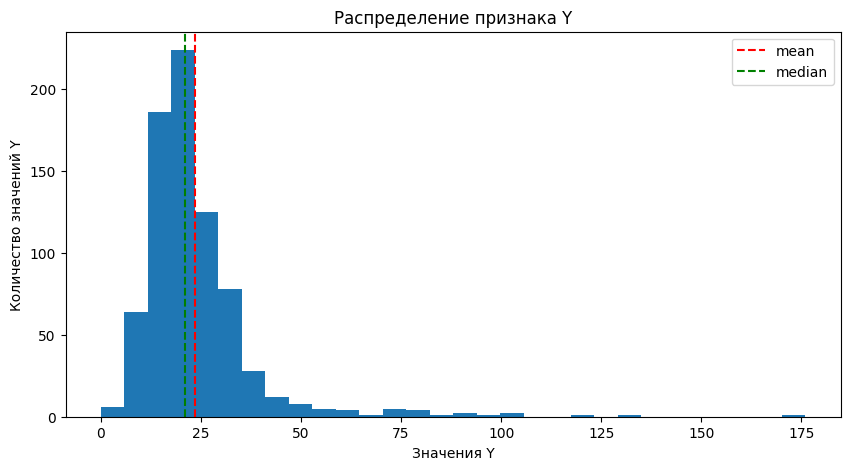

In [350]:
print(f"value counts:\n{df['Y'].value_counts()}")

plt.figure(figsize=(10, 5))
plt.hist(df['Y'], bins=30)
plt.title('Распределение признака Y')
plt.xlabel('Значения Y')
plt.ylabel('Количество значений Y')
mean_Y = df['Y'].mean()
median_Y = df['Y'].median()
plt.axvline(x=mean_Y , color='r', linestyle='--', label='mean')
plt.axvline(x=median_Y, color='g', linestyle='--', label='median')
print(f'\nMean rate: {mean_Y}')
print(f'\nMedian rate: {median_Y}')
plt.legend()
plt.show()

Глядя на график распределения Y, можно сказать, что:
- Распределение асимметрично — наблюдается правосторонний (положительный) перекос: основная масса значений сосредоточена в пределах 15–30, при этом хвост распределения тянется далеко вправо.
- Среднее значение Y превышает медиану, что подтверждает наличие положительной асимметрии: среднее: ~23.6 и медиана: ~21.0

#### Вывод:
Распределение Y не является нормальным, поэтому перед построением регрессионной модели может быть целесообразно применить логарифмическое преобразование """чтобы стабилизировать дисперсию и уменьшить влияние выбросов""".

### Анализ остальных признаков
#### Распределения остальных признаков


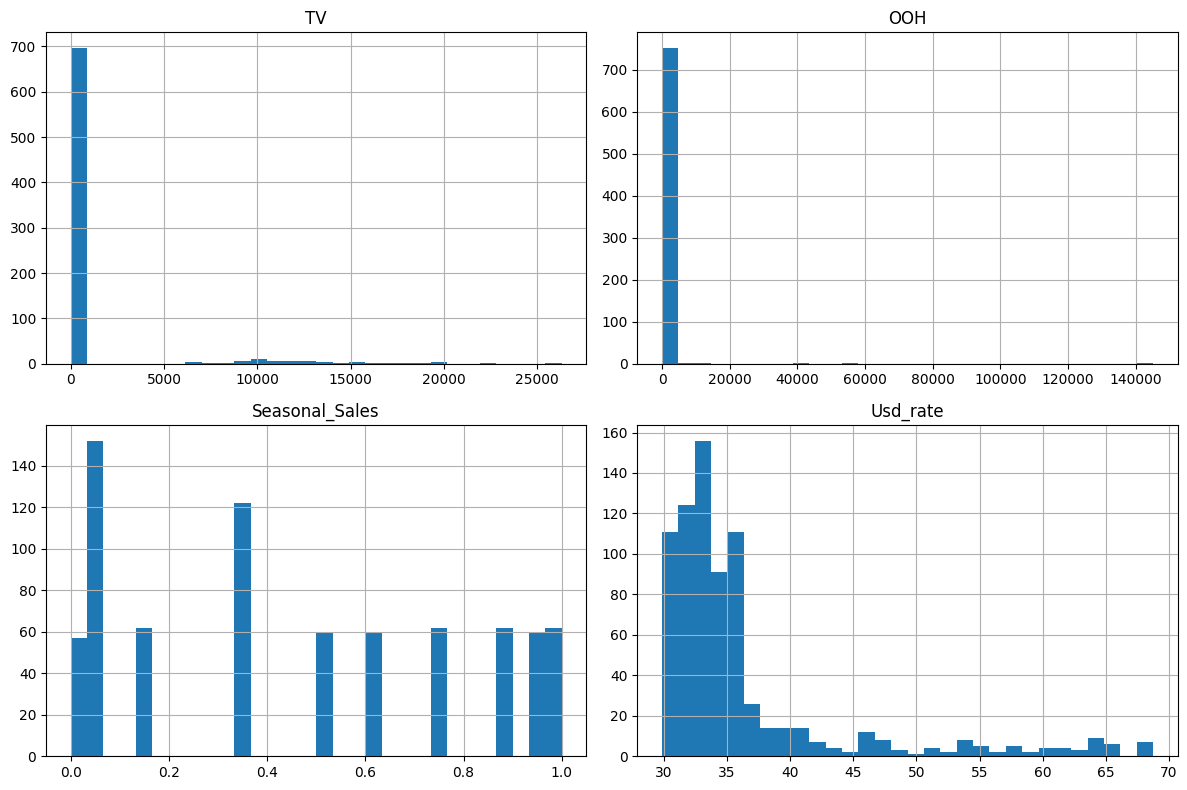

In [351]:
import seaborn as sns

numeric_cols = ['Y', 'TV', 'OOH', 'Seasonal_Sales', 'Usd_rate']
df[numeric_cols[1:]].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

На данных гистограммах заметим, что:
- TV:
    - Распределение крайне смещено влево, основная масса значений — в районе 0, значит, TV-реклама запускалась редко
    - Длинный правый хвост: вероятно, редкие, рекламные кампании
- ООН:
    - Идентично с распределением TV
- Seasonal_sales:
    - Значения распределены по кластерам
    - Есть ступенчатость, что указывает на дискретность
- Usd_rate:
    - Большинство значений сконцентрировано в области 30-36, далее заметем хвост -> датасет ограничен по дате, где значения звонков сосредоточены в период, когда usd ~ 30-40

#### График динамики целевой величины с рекламной активностью

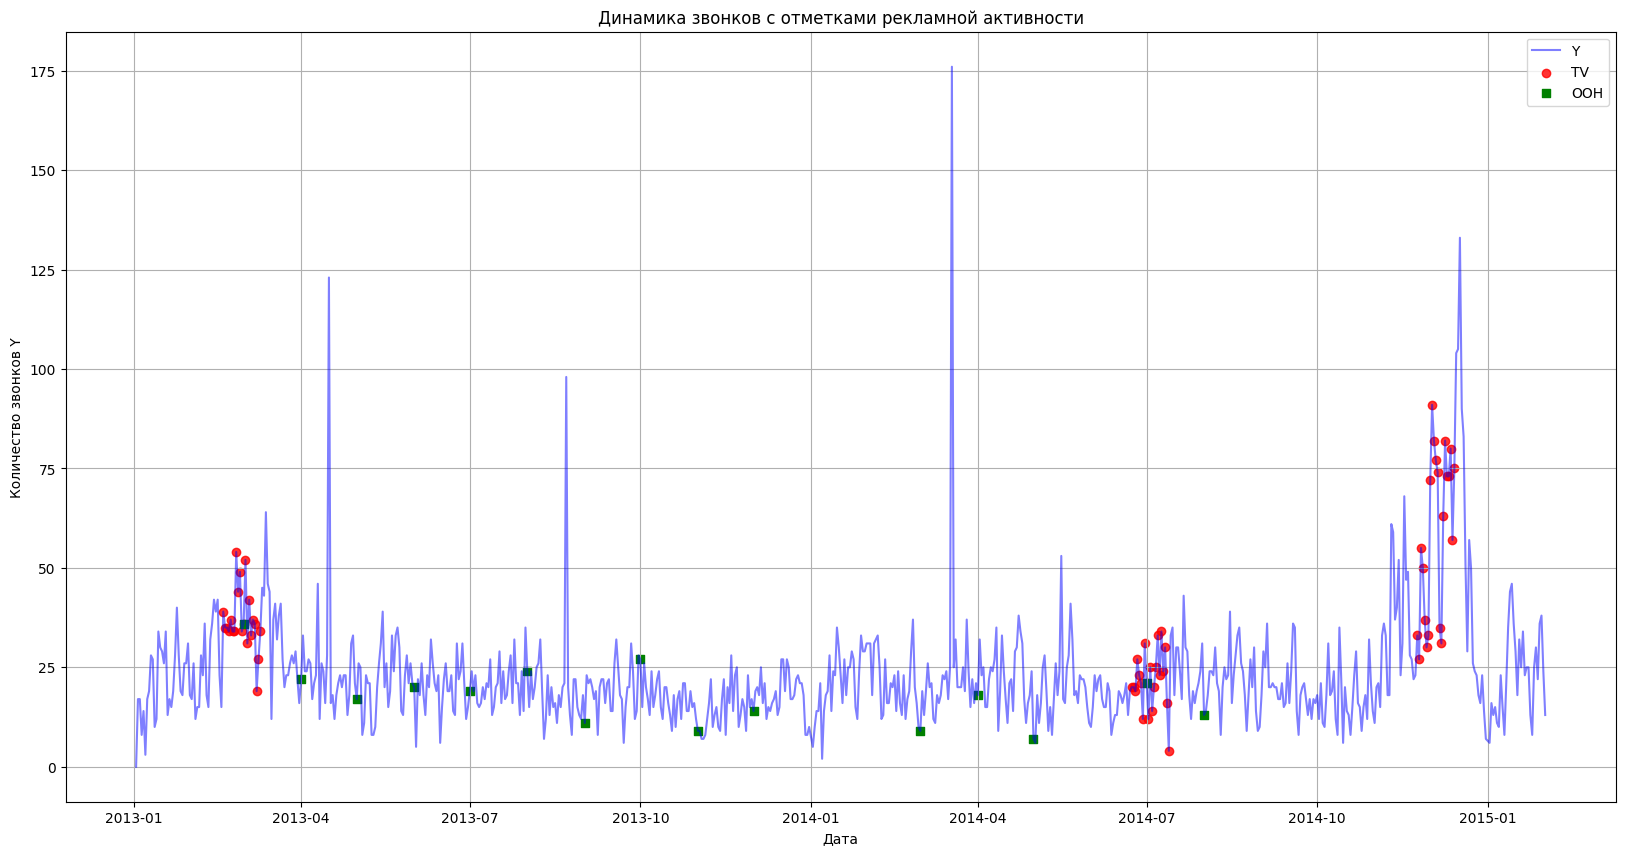

In [352]:
plt.figure(figsize=(20, 10))
plt.plot(df['Date'], df['Y'], label='Y', color='blue', alpha = 0.5)

tv_active = df[df['TV'] > 0]
plt.scatter(tv_active['Date'], tv_active['Y'], color='red',
            marker='o', label='TV', alpha=0.8)

ooh_active = df[df['OOH'] > 0]
plt.scatter(ooh_active['Date'], ooh_active['Y'], color='green',
            marker='s', label='OOH', alpha=1)

plt.title('Динамика звонков с отметками рекламной активности')
plt.xlabel('Дата')
plt.ylabel('Количество звонков Y')
plt.legend()
plt.grid()
plt.show()

- Красные (TV) и зелёные (OOH) маркеры не совпадают с устойчивыми всплесками звонков (за исключением конца 2014 - наблюдается пик звонков после рекламной кампании на TV). Это может означать, что:

    - Реклама неэффективна в привлечении звонков.

    - Её влияние слишком слабое на фоне других факторов (например, сезонность, конкуренция, экономическая ситуация).


In [353]:
df['TV_active'] = df['TV'] > 0
pd.pivot_table(df, values='Y', columns= 'TV_active', aggfunc=['mean', 'count'])

mean            count      
TV_active      False      True  False True 
Y          22.231322  39.047619   696    63

В дни, когда нет рекламы:
количество звонков ~ 22
количество дней: 696

В дни, когда есть реклама:
количество звонков ~ 39
количество дней: 63

### Вывод:
- Реклама на ТВ влияет на количество звонков, но не так сильно. К примеру, на момент апреля 2013 и 2014 года, а также на момент ~августа 2013 нет зависимости звонков от рекламы TV или ООН

Также попробуем создать новый признак, основанный на дате - dayofweek - workday/weekend

In [354]:
df['dayofweek'] = df['Date'].dt.dayofweek
print(df['dayofweek'].value_counts())

dayofweek
4    109
6    109
5    109
3    108
2    108
0    108
1    108
Name: count, dtype: int64


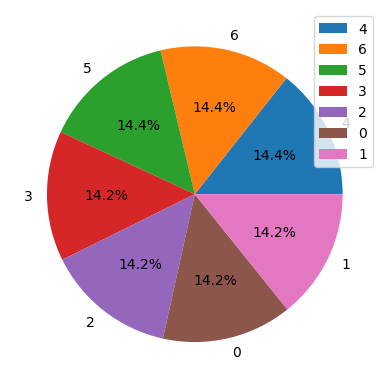

In [355]:
data = df['dayofweek'].value_counts()
plt.pie(data.values, labels = data.index, autopct = '%1.1f%%')
plt.legend()
plt.show()

Date
0    2790.0
1    3043.0
2    2863.0
3    2859.0
4    2601.0
5    1948.0
6    1829.0
Name: Y, dtype: float64


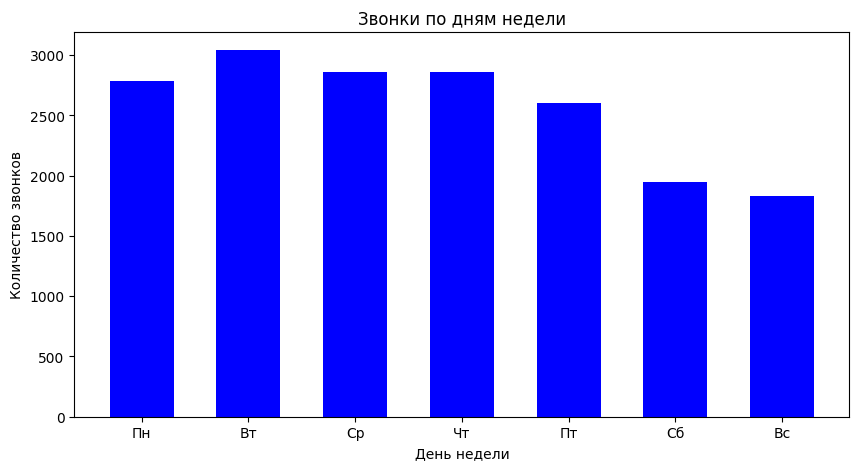

In [356]:
calls_by_day = df.groupby(df['Date'].dt.dayofweek)['Y'].sum()
print(calls_by_day)
days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

plt.figure(figsize=(10, 5))
plt.bar(days, calls_by_day, color='blue', width=0.6)

plt.title('Звонки по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество звонков')

plt.show()

### Корреляционный анализ

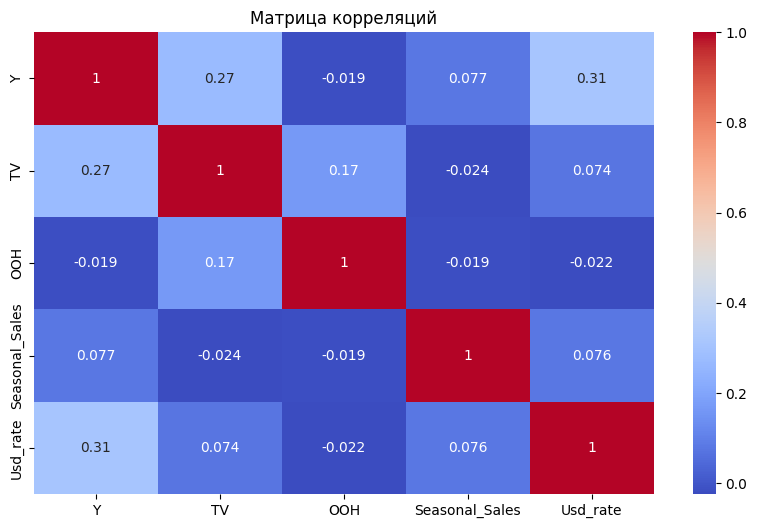

In [357]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()

Анализурая данную матрицу, можно сказать, что сила связи между признаками:
- Y(Usd_rate) = 0.31 - умеренная


В остальных случаях связь либо слабая/вовсе нет

### График звонков от курса доллара

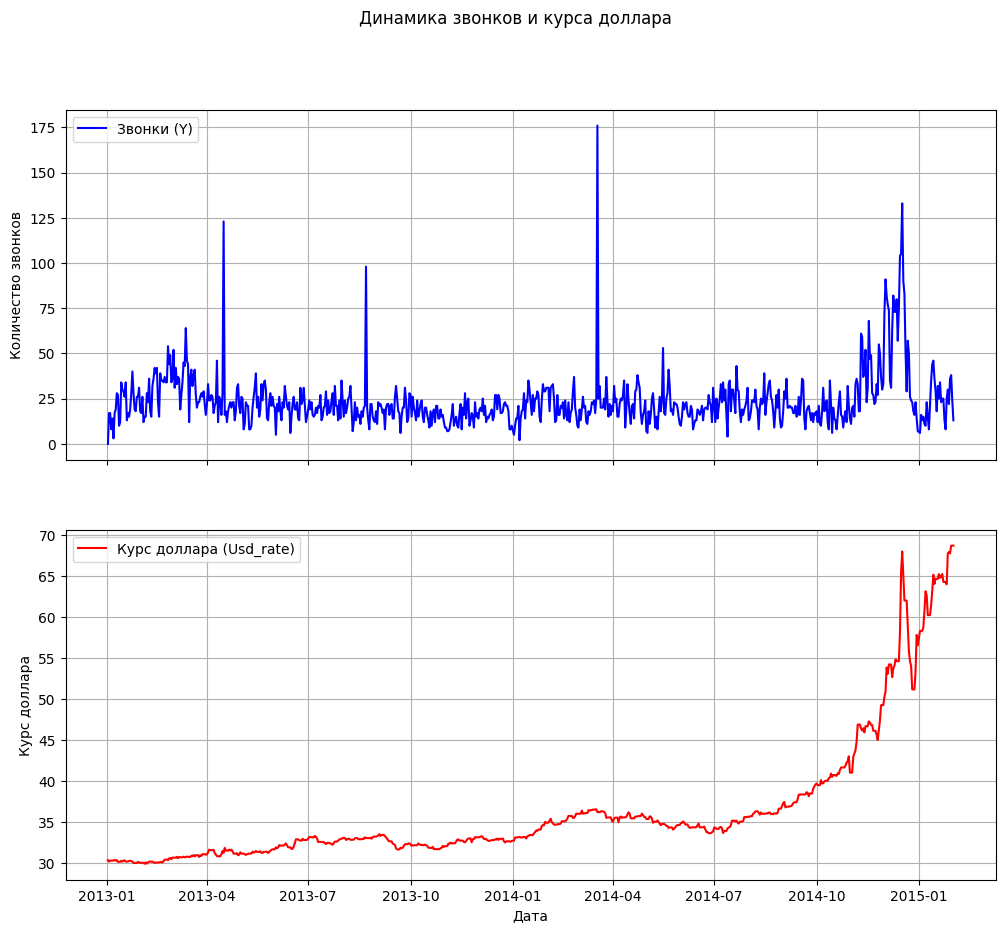

In [358]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True)

ax1.plot(df['Date'], df['Y'], color='blue', label='Звонки (Y)')
ax1.set_ylabel('Количество звонков')
ax1.tick_params(axis='y')
ax1.grid(True)
ax1.legend(loc='upper left')

ax2.plot(df['Date'], df['Usd_rate'], color='red', label='Курс доллара (Usd_rate)')
ax2.set_xlabel('Дата')
ax2.set_ylabel('Курс доллара')
ax2.tick_params(axis='y')
ax2.grid(True)
ax2.legend(loc='upper left')

plt.suptitle('Динамика звонков и курса доллара')

plt.show()

При увеличении курса к концу 2014 года заметно, что увеличилось число звонков.
Также, если обратить внимание на момент ~апреля 2014 года, то можно заметить, что также незначительно увеличелось Usd_rate, но это очень хорошо отразилось на количестве звонков

### Анализ по месяцам/годам
группировка по месяцам:

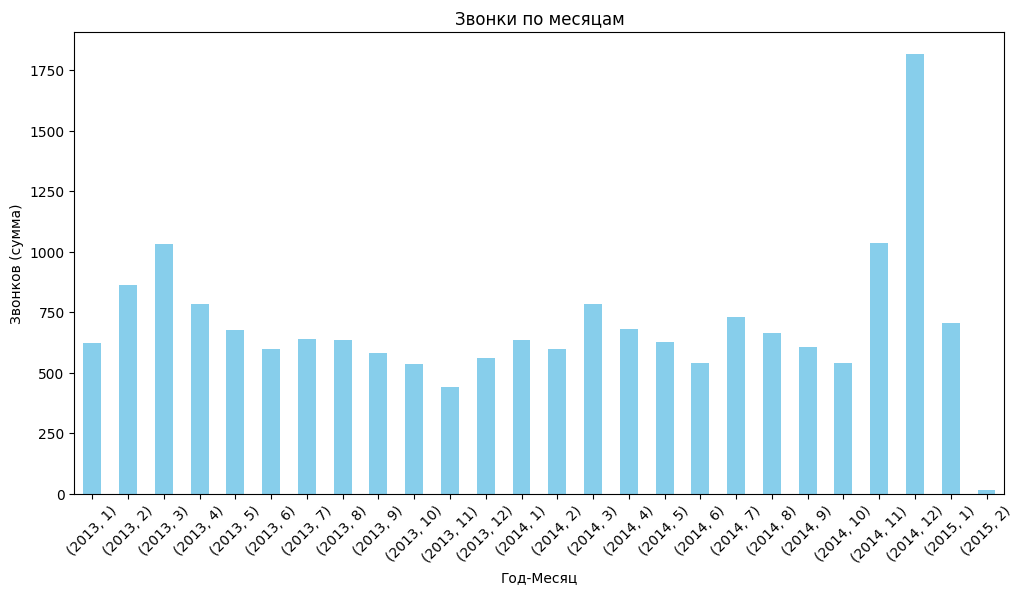

In [359]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
monthly_data = df.groupby(['Year', 'Month']).agg({'Y': 'sum', 'TV': 'sum', 'OOH': 'sum'})

plt.figure(figsize=(12, 6))
monthly_data['Y'].plot(kind='bar', color='skyblue')
plt.title('Звонки по месяцам')
plt.xlabel('Год-Месяц')
plt.ylabel('Звонков (сумма)')
plt.xticks(rotation=45)
plt.show()

Заметим, что больше всего звонков было сделано на момент 12.2024. из прошлого графика мы знаем, что это связано с увеличением курса

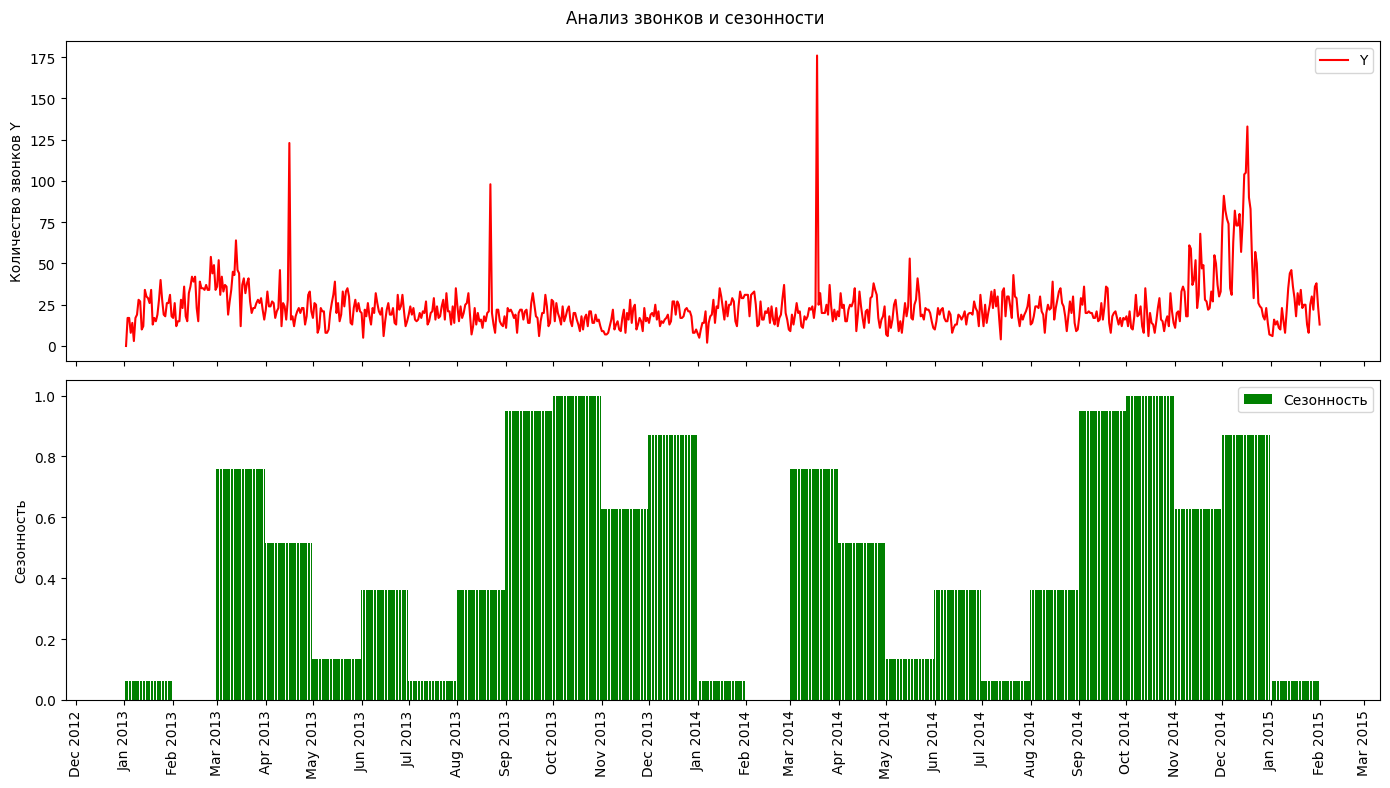

In [360]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 8), sharex=True)

ax1.plot(df['Date'], df['Y'], color='red', label='Y')

ax1.set_ylabel('Количество звонков Y')
ax1.legend()

ax2.bar(df['Date'], df['Seasonal_Sales'], color='green', label='Сезонность')
ax2.set_ylabel('Сезонность')
ax2.legend()
import matplotlib.dates as mdates
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=90)


plt.suptitle('Анализ звонков и сезонности')
plt.tight_layout()
plt.show()

Тут можем заметить некую особенность "Сезонности": здесь наблюдается, что в период с января по март никакой активности нет, а пики в свою очередь приурочены к датам: апрель 2013, август 2013, март 2014, декабрь 2014

### б) построить регрессионную модель, выполнить её валидацию на отдельной подвыборке;

разобьем датасет на обучающую и тестовую выборки, но перед этим создадим признак day и удалим Date, т.к. fit не работает с признаком типа timestamp

In [361]:
df['day'] = df['Date'].dt.day

df.drop(columns=['Date', 'TV', 'Year', 'Month'], inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 759 entries, 1 to 761
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Y               759 non-null    float64
 1   OOH             759 non-null    float64
 2   Seasonal_Sales  759 non-null    float64
 3   Usd_rate        759 non-null    float64
 4   TV_active       759 non-null    bool   
 5   dayofweek       759 non-null    int32  
 6   day             759 non-null    int32  
dtypes: bool(1), float64(4), int32(2)
memory usage: 36.3 KB


In [362]:
df['TV_active'] = df['TV_active'].astype(int)

In [363]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 759 entries, 1 to 761
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Y               759 non-null    float64
 1   OOH             759 non-null    float64
 2   Seasonal_Sales  759 non-null    float64
 3   Usd_rate        759 non-null    float64
 4   TV_active       759 non-null    int64  
 5   dayofweek       759 non-null    int32  
 6   day             759 non-null    int32  
dtypes: float64(4), int32(2), int64(1)
memory usage: 41.5 KB


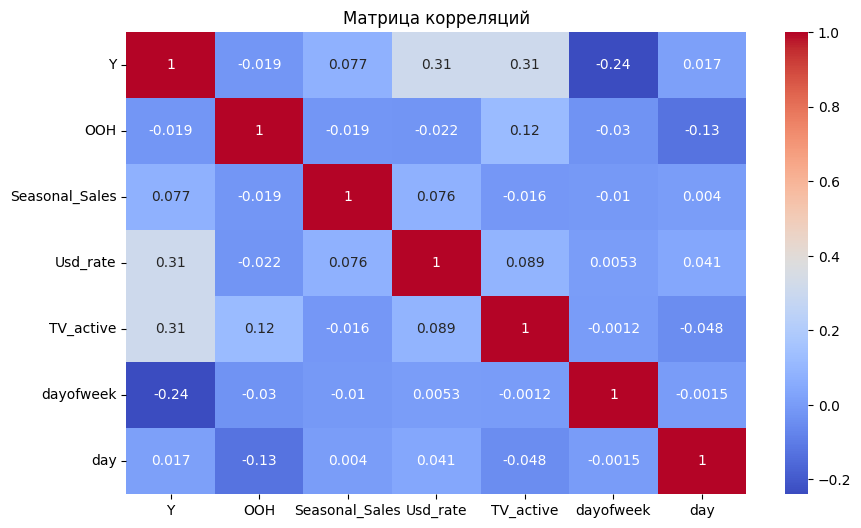

In [364]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()

In [365]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Y']).values
y = df['Y'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [366]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [367]:
from sklearn.metrics import mean_absolute_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)
mean_y = df['Y'].mean()
print(f"Среднее значение Y: {mean_y:.2f}")

r2 = r2_score(y_test, y_pred)
print(f"R2 метрика: {r2}")

MAE: 7.159166666666667
Среднее значение Y: 23.63
R2 метрика: 0.4077915065604738
